# Evaluating a PMI threshold for Wikidata biomedical relations with an independent verdict (Jev)

This notebook reproduces every number, table and figure in the accompanying paper.

**What it does**

1. Loads the two verdict files produced by the Jev run (`Low_PMI.xlsx`, `Not_Available_in_PubMed.xlsx`).
2. Summarises their structure (counts, entity types, duplicates).
3. Computes the share of relations judged accurate **per PMI value**, with confidence intervals.
4. Tests how well PMI predicts the verdict, with and without control for relation type.
5. Compares relations with *no* PubMed association (PMI = -10) with those of *weak* association (PMI < 2).
6. Provides, behind switches that are **off by default**, the code needed to regenerate the inputs: PMI from Entrez counts (paper Eq. 1), Wikidata labels, and Jev verdicts.
7. Provides `evaluate_threshold()`, a ready-to-run test of the PMI = 2 threshold for when verdicts for PMI >= 2 become available, and a sample-size calculation for it.

**Input files.** `Low_PMI.xlsx` and `Not_Available_in_PubMed.xlsx`, exactly as originally supplied (first sheet, 10 columns). Put them next to the notebook, in a `data/` folder, or - in Google Colab - upload them when prompted.

**What it cannot do.** The supplied data contain only PMI < 2 and the default value -10. Nothing here can say whether relations at PMI >= 2 are more accurate than those below it.

**Outcome definition.** "Accurate" always means that Jev returned `true` for a prompt containing only three English labels. It is not human-verified truth.

## 0. Configuration

In [1]:
import os, json, math, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import rankdata
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Maximum Likelihood.*")

# ---- switches (all heavy / networked steps are OFF by default) ----------------
RUN_ENTREZ = False   # recompute PMI from PubMed counts (needs network + email, slow)
RUN_LABELS = False   # re-fetch Wikidata labels (needs network)
RUN_JEV    = False   # re-run Jev verdicts (needs TYPESAFE_API_KEY, network, ~1 h per 15k rows)

SEED = 20241
N_BOOT = 500                      # bootstrap replicates for AUC intervals
PMI_THRESHOLD = 2.0               # paper, Sec. 3.2 / 4.2
PMI_DEFAULT = -10                 # paper, Eq. 1 (N(x,y) = 0)
# Properties treated as non-biomedical (researcher-defined, see paper Sec. 3.4).
# The Heliyon paper itself names P530 and P47 as non-biomedical; P463 and P17 are added here.
NONBIO = {"P530": "diplomatic relation", "P47": "shares border with",
          "P463": "member of", "P17": "country"}

OUT = Path("results"); OUT.mkdir(exist_ok=True)
rng = np.random.default_rng(SEED)
R = {}   # every headline number is stored here and written to results/results.json
print("Configuration OK")

Configuration OK


## 1. Load the data

In [2]:
def find(name):
    for d in [Path("."), Path("data"), Path("/content"), Path("/mnt/user-data/uploads")]:
        if (d / name).exists():
            return d / name
    try:                                              # Google Colab: ask for the files
        from google.colab import files
        print(f"Please upload {name}")
        files.upload()
        if Path(name).exists():
            return Path(name)
    except ImportError:
        pass
    raise FileNotFoundError(f"{name} not found: place it next to the notebook or in ./data")

low = pd.read_excel(find("Low_PMI.xlsx"))                      # original file, first sheet
na  = pd.read_excel(find("Not_Available_in_PubMed.xlsx"))      # original file, first sheet

NEEDED = ["subject", "subjectID", "object", "objectID", "prop", "PMI",
          "subject_label", "object_label", "prop_label", "choice"]
for name, d in [("Low_PMI.xlsx", low), ("Not_Available_in_PubMed.xlsx", na)]:
    missing = [c for c in NEEDED if c not in d.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")
    d["PMI"] = pd.to_numeric(d["PMI"], errors="coerce")
    d["choice"] = d["choice"].astype(str).str.strip().str.lower()

df = pd.concat([low.assign(group="low_pmi"), na.assign(group="no_assoc")], ignore_index=True)
df["true"]  = (df["choice"] == "true").astype(int)
df["maybe"] = (df["choice"] == "maybe").astype(int)
df["pmi_bin"] = np.floor(df["PMI"]).astype(int)          # the paper rounds PMI down
df["nonbio"]  = df["prop"].isin(NONBIO)
R["n_low"], R["n_na"] = len(low), len(na)
print(df.groupby("group").size())
print("PMI range, low-PMI file:", low["PMI"].min(), "to", low["PMI"].max(),
      "| no-association file PMI values:", sorted(na["PMI"].unique()))
df.head(3)

group
low_pmi     15925
no_assoc    24800
dtype: int64
PMI range, low-PMI file: -5.731661594 to 1.999826338 | no-association file PMI values: [np.int64(-10)]


,subject,subjectID,object,objectID,prop,PMI,subject_label,object_label,prop_label,choice,group,true,maybe,pmi_bin,nonbio
0,Q58833983,D064726,Q12136,D004194,P31,-5.731662,triple-negative breast neoplasm,disease,instance of,true,low_pmi,1,0,-6,False
1,Q4082046,D063146,Q623,D002244,P527,-5.628619,polycomb-group proteins,carbon,has part(s),false,low_pmi,0,0,-6,False
2,Q382370,D045908,Q835153,D010808,P923,-5.225243,mpox,physical examination,medical examination,false,low_pmi,0,0,-6,False


## 2. Data audit

In [3]:
def audit(d):
    return {
        "rows": len(d),
        "distinct_properties": d["prop"].nunique(),
        "distinct_subjects": d["subject"].nunique(),
        "distinct_objects": d["object"].nunique(),
        "duplicate_spo_rows": int(d.duplicated(["subject", "prop", "object"]).sum()),
        "subject_label_is_QID": int(d["subject_label"].astype(str).str.fullmatch(r"Q\d+").sum()),
        "object_label_is_QID":  int(d["object_label"].astype(str).str.fullmatch(r"Q\d+").sum()),
        "same_MeSH_id_both_ends": int((d["subjectID"] == d["objectID"]).sum()),
        "subject_ID_prefix_D": int(d["subjectID"].astype(str).str[0].eq("D").sum()),
        "subject_ID_prefix_C": int(d["subjectID"].astype(str).str[0].eq("C").sum()),
        "object_ID_prefix_C":  int(d["objectID"].astype(str).str[0].eq("C").sum()),
    }
aud = pd.DataFrame({"low_pmi": audit(low), "no_assoc": audit(na)})
overlap = set(zip(low.subject, low.prop, low.object)) & set(zip(na.subject, na.prop, na.object))
R["audit"] = aud.to_dict(); R["triples_in_both_files"] = len(overlap)
R["share_subject_C_no_assoc"] = float(aud.loc["subject_ID_prefix_C", "no_assoc"] / len(na))
display(aud)
print("(subject, property, object) triples present in both files:", len(overlap))
print("Share of no-association subjects that are MeSH supplementary concepts (C...):",
      round(100 * R["share_subject_C_no_assoc"], 1), "%")

,low_pmi,no_assoc
rows,15925,24800
distinct_properties,129,118
distinct_subjects,5853,10340
distinct_objects,1876,4152
duplicate_spo_rows,46,146
subject_label_is_QID,33,36
object_label_is_QID,46,157
same_MeSH_id_both_ends,0,44
subject_ID_prefix_D,15925,7062
subject_ID_prefix_C,0,17732


(subject, property, object) triples present in both files: 26
Share of no-association subjects that are MeSH supplementary concepts (C...): 71.5 %


## 3. Verdict distribution

`true` / `maybe` / `false` are the three categories Jev was allowed to return.

,group,verdict,k,n,pct,ci_lo,ci_hi
0,low_pmi,true,10407,15925,65.35,64.61,66.09
1,low_pmi,maybe,163,15925,1.02,0.88,1.19
2,low_pmi,false,5355,15925,33.63,32.90,34.36
3,no_assoc,true,17328,24800,69.87,69.30,70.44
4,no_assoc,maybe,196,24800,0.79,0.69,0.91
5,no_assoc,false,7276,24800,29.34,28.78,29.91


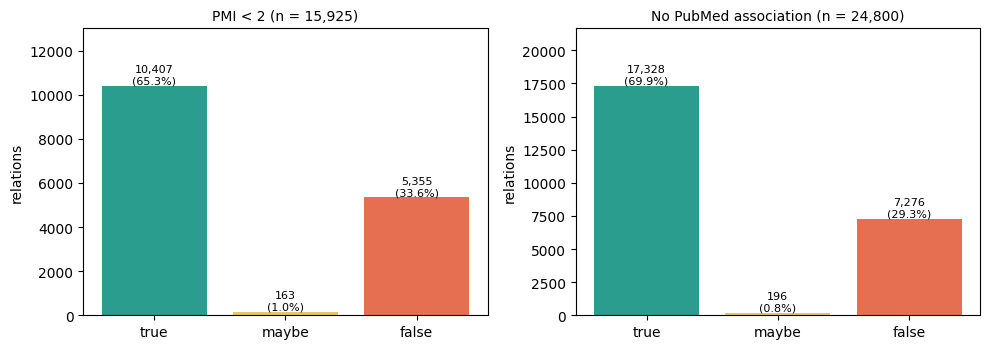

In [4]:
def rate_ci(k, n):
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    return 100 * k / n, 100 * lo, 100 * hi

vd = []
for g, d in df.groupby("group"):
    for c in ["true", "maybe", "false"]:
        k = int((d["choice"] == c).sum()); r, lo, hi = rate_ci(k, len(d))
        vd.append((g, c, k, len(d), r, lo, hi))
vd = pd.DataFrame(vd, columns=["group", "verdict", "k", "n", "pct", "ci_lo", "ci_hi"]).round(2)
vd.to_csv(OUT / "table_verdicts.csv", index=False)
R["verdicts"] = vd.to_dict("records")
display(vd)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a, (g, t) in zip(ax, [("low_pmi", "PMI < 2 (n = 15,925)"), ("no_assoc", "No PubMed association (n = 24,800)")]):
    s = vd[vd.group == g].set_index("verdict").loc[["true", "maybe", "false"]]
    a.bar(s.index, s.k, color=["#2a9d8f", "#e9c46a", "#e76f51"])
    for i, (k, p) in enumerate(zip(s.k, s.pct)):
        a.text(i, k, f"{k:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=8)
    a.set_ylim(0, s.k.max() * 1.25); a.set_title(t, fontsize=10); a.set_ylabel("relations")
plt.tight_layout(); plt.savefig(OUT / "fig1_verdicts.png", dpi=160); plt.show()

## 4. Accuracy rate per PMI value

PMI is rounded **down** (floor), as in the paper. For each bin we report the share of relations that Jev judged `true` with a 95% Wilson interval. The primary view uses all relations; the second removes the properties defined as non-biomedical (reason in Section 5).

In [5]:
def bin_table(d, key="pmi_bin", min_n=1):
    g = d.groupby(key)["true"].agg(n="size", k="sum").reset_index()
    g = g[g.n >= min_n]
    ci = g.apply(lambda r: rate_ci(int(r.k), int(r.n)), axis=1, result_type="expand")
    g[["pct_true", "ci_lo", "ci_hi"]] = ci
    return g.round(1)

low_d = df[df.group == "low_pmi"].copy()
tab_all  = bin_table(low_d)
tab_bio  = bin_table(low_d[~low_d.nonbio])
low_d["pmi_half"] = np.floor(low_d["PMI"] * 2) / 2
tab_half = bin_table(low_d, key="pmi_half")
tab_all.to_csv(OUT / "table_rate_by_pmi_all.csv", index=False)
tab_bio.to_csv(OUT / "table_rate_by_pmi_biomedical.csv", index=False)
tab_half.to_csv(OUT / "table_rate_by_pmi_halfunit.csv", index=False)
R["rate_by_bin_all"] = tab_all.to_dict("records")
R["rate_by_bin_bio"] = tab_bio.to_dict("records")
print("All low-PMI relations"); display(tab_all)
print("Biomedical properties only"); display(tab_bio)

All low-PMI relations


,pmi_bin,n,k,pct_true,ci_lo,ci_hi
0,-6,4,1,25.0,4.6,69.9
1,-5,25,9,36.0,20.2,55.5
2,-4,162,67,41.4,34.1,49.1
3,-3,579,333,57.5,53.4,61.5
4,-2,1543,983,63.7,61.3,66.1
5,-1,3041,2024,66.6,64.9,68.2
6,0,4646,3036,65.3,64.0,66.7
7,1,5925,3954,66.7,65.5,67.9


Biomedical properties only


,pmi_bin,n,k,pct_true,ci_lo,ci_hi
0,-6,4,1,25.0,4.6,69.9
1,-5,25,9,36.0,20.2,55.5
2,-4,137,43,31.4,24.2,39.6
3,-3,386,171,44.3,39.4,49.3
4,-2,881,404,45.9,42.6,49.2
5,-1,1947,1015,52.1,49.9,54.3
6,0,3574,2031,56.8,55.2,58.4
7,1,4990,3089,61.9,60.5,63.2


In [6]:
# the no-association group has the single value -10
na_row = rate_ci(int(na["choice"].eq("true").sum()), len(na))
R["no_assoc_true_pct"] = na_row
print("No association (PMI = -10): %.1f%% true  (95%% CI %.1f-%.1f)" % na_row)

No association (PMI = -10): 69.9% true  (95% CI 69.3-70.4)


## 5. Why the pooled curve is misleading: composition by relation type

Verdict rates differ enormously by property (for example *diplomatic relation* is judged accurate far more often than *found in taxon*). If properties are unevenly spread across PMI bins, the pooled curve mixes a PMI effect with a composition effect.

,prop,prop_label,n,k,pct_true
100,P530,diplomatic relation,3718,3461,93.1
66,P279,subclass of,1714,1313,76.6
99,P527,has part(s),1492,1006,67.4
75,P31,instance of,1456,1193,81.9
109,P681,cell component,1418,595,42.0
48,P1995,health specialty,1105,494,44.7
112,P703,found in taxon,657,77,11.7
118,P780,symptoms and signs,643,549,85.4
110,P682,biological process,385,61,15.8
53,P2176,drug or therapy used for treatment,327,132,40.4


pmi_bin,-6,-5,-4,-3,-2,-1,0,1
pct_P530,0.0,0.0,14.8,33.3,42.7,35.2,21.8,12.8
pct_nonbio,0.0,0.0,15.4,33.3,42.9,36.0,23.1,15.8


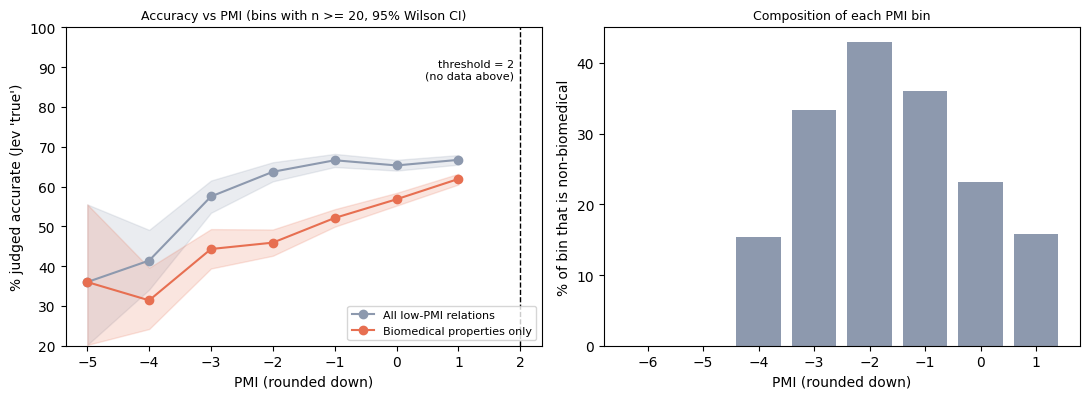

In [7]:
prop_tab = (low_d.groupby(["prop", "prop_label"])["true"].agg(n="size", k="sum").reset_index()
            .assign(pct_true=lambda x: (100 * x.k / x.n).round(1)).sort_values("n", ascending=False))
prop_tab.head(15).to_csv(OUT / "table_top_properties_low.csv", index=False)
display(prop_tab.head(12))

share_p530 = (low_d.assign(p530=low_d["prop"] == "P530").groupby("pmi_bin")["p530"].mean() * 100).round(1)
share_nonbio = (low_d.groupby("pmi_bin")["nonbio"].mean() * 100).round(1)
comp = pd.DataFrame({"pct_P530": share_p530, "pct_nonbio": share_nonbio})
R["share_p530_by_bin"] = share_p530.to_dict(); R["share_nonbio_by_bin"] = share_nonbio.to_dict()
R["p530_share_low"] = float((low_d["prop"] == "P530").mean() * 100)
R["nonbio_share_low"] = float(low_d["nonbio"].mean() * 100)
display(comp.T)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
for d, lab, c in [(tab_all, "All low-PMI relations", "#8d99ae"), (tab_bio, "Biomedical properties only", "#e76f51")]:
    d = d[d.n >= 20]
    ax[0].plot(d.pmi_bin, d.pct_true, "o-", color=c, label=lab)
    ax[0].fill_between(d.pmi_bin, d.ci_lo, d.ci_hi, color=c, alpha=.18)
ax[0].axvline(PMI_THRESHOLD, color="k", ls="--", lw=1)
ax[0].text(1.9, 92, "threshold = 2\n(no data above)", ha="right", va="top", fontsize=8)
ax[0].set(xlabel="PMI (rounded down)", ylabel="% judged accurate (Jev 'true')", ylim=(20, 100))
ax[0].set_title("Accuracy vs PMI (bins with n >= 20, 95% Wilson CI)", fontsize=9); ax[0].legend(fontsize=8, loc="lower right")
ax[1].bar(comp.index, comp.pct_nonbio, color="#8d99ae")
ax[1].set(xlabel="PMI (rounded down)", ylabel="% of bin that is non-biomedical")
ax[1].set_title("Composition of each PMI bin", fontsize=9)
plt.tight_layout(); plt.savefig(OUT / "fig2_rate_vs_pmi.png", dpi=160); plt.show()

## 6. Does PMI predict the verdict?

Five complementary measures on the PMI < 2 set:

* Spearman correlation between PMI and the binary outcome.
* The area under the ROC curve (AUC) of PMI as a score for `true`.
* Logistic regression, crude and **adjusted for property** (property fixed effects, standard errors clustered by subject entity because the same subject recurs many times).
* A **within-property pooled AUC** with a stratified bootstrap interval (resampling rows within each property).
* The odds ratio for PMI < 0 versus 0 <= PMI < 2, adjusted for property.

In [8]:
def auc_rank(y, s):
    y = np.asarray(y); s = np.asarray(s)
    n1 = y.sum(); n0 = len(y) - n1
    if n1 == 0 or n0 == 0: return np.nan
    r = rankdata(s)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

def pooled_within_auc(d):
    num = den = 0.0
    for _, g in d.groupby("prop"):
        y = g["true"].values; n1 = y.sum(); n0 = len(y) - n1
        if n1 == 0 or n0 == 0: continue
        num += auc_rank(y, g["PMI"].values) * n1 * n0; den += n1 * n0
    return num / den

def or_row(res, term):
    b = res.params[term]; lo, hi = res.conf_int().loc[term]
    return float(np.exp(b)), float(np.exp(lo)), float(np.exp(hi)), float(res.pvalues[term])

def fit(formula, d, cluster=True):
    kw = dict(disp=0, maxiter=300)
    if cluster:
        kw.update(cov_type="cluster", cov_kwds={"groups": pd.factorize(d["subject"])[0]})
    return smf.logit(formula, d).fit(**kw)

L = low_d.copy()
L["neg"] = (L["PMI"] < 0).astype(int)
Lb = L[~L.nonbio]

rho, rho_p = stats.spearmanr(L.PMI, L.true)
R["spearman"] = (float(rho), float(rho_p)); R["auc_all"] = float(auc_rank(L.true, L.PMI))
R["auc_bio"] = float(auc_rank(Lb.true, Lb.PMI))

m_crude = fit("true ~ PMI", L)
m_adj   = fit("true ~ PMI + C(prop)", L)
m_bio   = fit("true ~ PMI", Lb)
m_bio_adj = fit("true ~ PMI + C(prop)", Lb)
m_neg   = fit("true ~ neg + C(prop)", L)
R["or_crude"] = or_row(m_crude, "PMI"); R["or_adj"] = or_row(m_adj, "PMI")
R["or_bio_crude"] = or_row(m_bio, "PMI"); R["or_bio_adj"] = or_row(m_bio_adj, "PMI")
R["or_neg_adj"] = or_row(m_neg, "neg")

# within-property pooled AUC + stratified bootstrap
groups = [g for _, g in L.groupby("prop")]
w_obs = pooled_within_auc(L)
boot = []
for _ in range(N_BOOT):
    parts = [g.iloc[rng.integers(0, len(g), len(g))] for g in groups]
    boot.append(pooled_within_auc(pd.concat(parts)))
R["within_auc"] = (float(w_obs), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5)))

res = pd.DataFrame({
    "measure": ["Spearman rho (PMI vs true)", "AUC, all relations", "AUC, biomedical only",
                "Within-property pooled AUC (95% bootstrap CI)",
                "OR per +1 PMI, crude", "OR per +1 PMI, property-adjusted",
                "OR per +1 PMI, biomedical only, crude", "OR per +1 PMI, biomedical only, property-adjusted",
                "OR for PMI<0 vs 0..2, property-adjusted"],
    "value": [f"{rho:.3f} (p={rho_p:.1e})", f"{R['auc_all']:.3f}", f"{R['auc_bio']:.3f}",
              "%.3f (%.3f-%.3f)" % R["within_auc"],
              "%.2f (%.2f-%.2f), p=%.1e" % R["or_crude"], "%.2f (%.2f-%.2f), p=%.1e" % R["or_adj"],
              "%.2f (%.2f-%.2f), p=%.1e" % R["or_bio_crude"], "%.2f (%.2f-%.2f), p=%.1e" % R["or_bio_adj"],
              "%.2f (%.2f-%.2f), p=%.1e" % R["or_neg_adj"]]})
res.to_csv(OUT / "table_pmi_association.csv", index=False)
display(res)

,measure,value
0,Spearman rho (PMI vs true),0.032 (p=5.7e-05)
1,"AUC, all relations",0.519
2,"AUC, biomedical only",0.566
3,Within-property pooled AUC (95% bootstrap CI),0.598 (0.584-0.612)
4,"OR per +1 PMI, crude","1.08 (1.03-1.14), p=3.2e-03"
5,"OR per +1 PMI, property-adjusted","1.37 (1.32-1.42), p=4.3e-57"
6,"OR per +1 PMI, biomedical only, crude","1.23 (1.19-1.27), p=4.8e-35"
7,"OR per +1 PMI, biomedical only, property-adjusted","1.35 (1.30-1.40), p=8.7e-58"
8,"OR for PMI<0 vs 0..2, property-adjusted","0.50 (0.45-0.55), p=4.5e-45"


In [9]:
# robustness: de-duplicate exact (subject, property, object) triples
Ld = L.drop_duplicates(["subject", "prop", "object"])
R["or_adj_dedup"] = or_row(fit("true ~ PMI + C(prop)", Ld), "PMI"); R["n_dedup"] = len(Ld)
# robustness: drop one reciprocal copy of each symmetric pair of any property
key = L.apply(lambda r: tuple(sorted((r.subject, r.object))) + (r["prop"],), axis=1)
Lu = L.loc[~key.duplicated()]
R["or_adj_unordered"] = or_row(fit("true ~ PMI + C(prop)", Lu), "PMI"); R["n_unordered"] = len(Lu)
print("de-duplicated n=%d  OR=%.2f (%.2f-%.2f)" % ((R["n_dedup"],) + R["or_adj_dedup"][:3]))
print("unordered-pair n=%d  OR=%.2f (%.2f-%.2f)" % ((R["n_unordered"],) + R["or_adj_unordered"][:3]))

de-duplicated n=15879  OR=1.37 (1.31-1.42)
unordered-pair n=13888  OR=1.36 (1.31-1.41)


### 6.1 Within-property view

,prop,label,n,pct_true,auc,lo,hi,spearman_p
3,P279,subclass of,1714,76.604,0.505,0.473,0.539,7.391636e-01
8,P682,biological process,385,15.844,0.530,0.452,0.607,4.509573e-01
4,P31,instance of,1456,81.937,0.559,0.520,0.597,2.872478e-03
5,P527,has part(s),1492,67.426,0.569,0.537,0.598,1.514014e-05
10,P780,symptoms and signs,643,85.381,0.575,0.504,0.644,1.945400e-02
9,P703,found in taxon,657,11.720,0.586,0.520,0.650,1.422371e-02
7,P681,cell component,1418,41.961,0.619,0.589,0.649,1.110697e-14
2,P2176,drug or therapy used for treatment,327,40.367,0.621,0.553,0.683,1.920085e-04
6,P530,diplomatic relation,3718,93.088,0.638,0.603,0.672,1.428333e-13
0,P1995,health specialty,1105,44.706,0.696,0.666,0.728,7.075293e-31


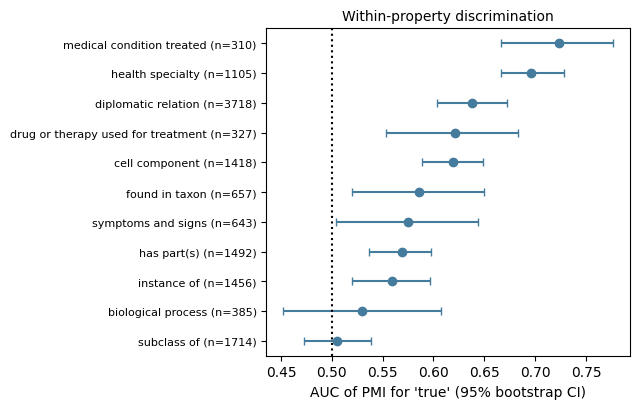

In [10]:
rows = []
for (p, lab), g in L.groupby(["prop", "prop_label"]):
    if len(g) < 300 or g["true"].nunique() < 2: continue
    y = g["true"].values; s = g["PMI"].values; a = auc_rank(y, s)
    bs = []
    for _ in range(1000):
        i = rng.integers(0, len(g), len(g)); bs.append(auc_rank(y[i], s[i]))
    rho_g, p_g = stats.spearmanr(s, y)
    rows.append((p, lab, len(g), 100 * y.mean(), a, np.nanpercentile(bs, 2.5), np.nanpercentile(bs, 97.5), p_g))
wp = pd.DataFrame(rows, columns=["prop", "label", "n", "pct_true", "auc", "lo", "hi", "spearman_p"]).sort_values("auc")
wp[["pct_true", "auc", "lo", "hi"]] = wp[["pct_true", "auc", "lo", "hi"]].round(3)
wp.to_csv(OUT / "table_within_property_auc.csv", index=False)
R["within_property"] = wp.to_dict("records")
display(wp)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(wp.auc, range(len(wp)), xerr=[wp.auc - wp.lo, wp.hi - wp.auc], fmt="o", color="#457b9d", capsize=3)
ax.axvline(0.5, color="k", ls=":"); ax.set_yticks(range(len(wp))); ax.set_yticklabels([f"{l} (n={n})" for l, n in zip(wp.label, wp.n)], fontsize=8)
ax.set_xlabel("AUC of PMI for 'true' (95% bootstrap CI)"); ax.set_title("Within-property discrimination", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "fig3_within_property_auc.png", dpi=160); plt.show()

## 7. No association (PMI = -10) versus weak association (PMI < 2)

The paper groups both as "deficient". If PMI measured plausibility monotonically, relations with *no* co-indexing should be judged accurate no more often than weakly co-indexed ones. We test this within property, restricted to biomedical properties.

Biomedical-only rate: low PMI 56.6% (n=11944)   no association 69.2% (n=23812)
Property-adjusted OR (no association vs PMI<2): 1.61 (1.51-1.73), p=1.9e-44


,prop,label,n_low,pct_low,n_na,pct_na,na_higher
0,P1995,health specialty,1105,44.7,1608,53.5,True
1,P2175,medical condition treated,310,45.8,702,80.1,True
2,P2176,drug or therapy used for treatment,327,40.4,740,69.3,True
3,P279,subclass of,1714,76.6,4687,75.0,False
4,P2868,subject has role,238,42.9,5034,75.7,True
5,P31,instance of,1456,81.9,2830,93.9,True
6,P366,has use,106,66.0,440,77.3,True
7,P527,has part(s),1492,67.4,995,76.9,True
8,P680,molecular function,227,57.3,144,68.8,True
9,P681,cell component,1418,42.0,1200,42.5,True


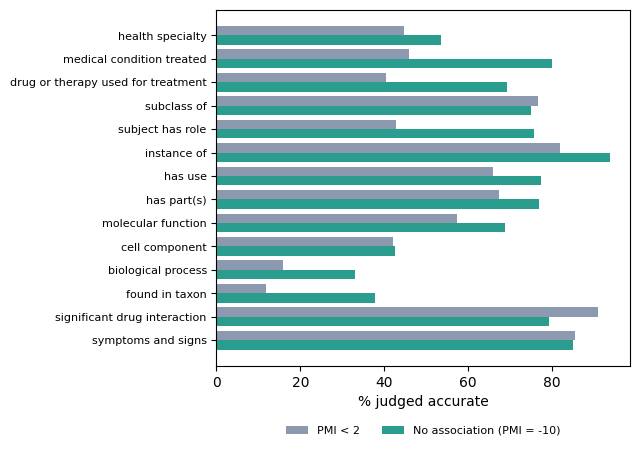

In [11]:
B = df[~df.nonbio].copy(); B["noassoc"] = (B.group == "no_assoc").astype(int)
R["bio_rate_low"]  = float(100 * B[B.noassoc == 0].true.mean()); R["bio_n_low"]  = int((B.noassoc == 0).sum())
R["bio_rate_na"]   = float(100 * B[B.noassoc == 1].true.mean()); R["bio_n_na"]   = int((B.noassoc == 1).sum())
m_na = fit("true ~ noassoc + C(prop)", B)
R["or_noassoc_adj"] = or_row(m_na, "noassoc")
print("Biomedical-only rate: low PMI %.1f%% (n=%d)   no association %.1f%% (n=%d)" %
      (R["bio_rate_low"], R["bio_n_low"], R["bio_rate_na"], R["bio_n_na"]))
print("Property-adjusted OR (no association vs PMI<2): %.2f (%.2f-%.2f), p=%.1e" % R["or_noassoc_adj"])

rows = []
for (p, lab), g in B.groupby(["prop", "prop_label"]):
    a, b = g[g.noassoc == 0].true, g[g.noassoc == 1].true
    if len(a) >= 100 and len(b) >= 100:
        rows.append((p, lab, len(a), 100 * a.mean(), len(b), 100 * b.mean()))
cmp_ = pd.DataFrame(rows, columns=["prop", "label", "n_low", "pct_low", "n_na", "pct_na"]).round(1)
cmp_["na_higher"] = cmp_.pct_na > cmp_.pct_low
cmp_.to_csv(OUT / "table_noassoc_vs_low_by_property.csv", index=False)
R["na_higher_props"] = (int(cmp_.na_higher.sum()), len(cmp_))
display(cmp_)

fig, ax = plt.subplots(figsize=(6.5, 4.6)); y = np.arange(len(cmp_))
ax.barh(y - .2, cmp_.pct_low, .4, label="PMI < 2", color="#8d99ae")
ax.barh(y + .2, cmp_.pct_na, .4, label="No association (PMI = -10)", color="#2a9d8f")
ax.set_yticks(y); ax.set_yticklabels(cmp_.label, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("% judged accurate"); ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
plt.tight_layout(); plt.savefig(OUT / "fig4_noassoc_vs_low.png", dpi=160); plt.show()

## 8. Internal consistency of the verdicts

In [12]:
def disagreements(d):
    out = {}
    g = d.groupby(["subject", "prop", "object"])["choice"].agg(list)
    g = g[g.map(len) > 1]
    out["duplicate_triple_groups"] = len(g)
    out["duplicate_groups_with_different_verdicts"] = int(g.map(lambda x: len(set(x)) > 1).sum())
    m = d[d["prop"] == "P530"].drop_duplicates(["subject", "object"])[["subject", "object", "choice"]]
    mm = m.merge(m, left_on=["subject", "object"], right_on=["object", "subject"], suffixes=("_f", "_r"))
    mm = mm[mm.subject_f < mm.object_f]
    out["P530_reciprocal_pairs"] = len(mm)
    out["P530_pairs_with_different_verdicts"] = int((mm.choice_f != mm.choice_r).sum())
    return out
cons = pd.DataFrame({"low_pmi": disagreements(low), "no_assoc": disagreements(na)})
R["consistency"] = cons.to_dict(); display(cons)

,low_pmi,no_assoc
duplicate_triple_groups,46,127
duplicate_groups_with_different_verdicts,7,4
P530_reciprocal_pairs,1836,445
P530_pairs_with_different_verdicts,18,22


## 9. Sample size needed to test the PMI = 2 threshold

To test the threshold, verdicts are needed for relations just above PMI 2. The calculation below gives the number of relations per side (just below / just above) needed to detect a given difference in the accuracy rate with 80% power at alpha = 0.05, starting from the observed rate in the highest available biomedical bin. It assumes independent observations, so the real requirement is larger (clustering by subject, property and reciprocal pairs).

In [13]:
p0 = float(tab_bio.loc[tab_bio.pmi_bin == 1, "pct_true"].iloc[0]) / 100
rows = []
for delta in [0.02, 0.03, 0.05, 0.10]:
    n = NormalIndPower().solve_power(effect_size=proportion_effectsize(p0 + delta, p0),
                                     alpha=0.05, power=0.80, ratio=1.0, alternative="two-sided")
    rows.append((p0, delta, math.ceil(n)))
ss = pd.DataFrame(rows, columns=["rate_below_threshold", "detectable_difference", "n_per_side"])
R["power_p0"] = p0; R["power_table"] = ss.to_dict("records")
display(ss)

,rate_below_threshold,detectable_difference,n_per_side
0,0.619,0.02,9157
1,0.619,0.03,4046
2,0.619,0.05,1438
3,0.619,0.10,346


## 10. `evaluate_threshold()` - ready for data above PMI = 2

Once Jev (or, better, human) labels exist for relations with PMI >= 2, this function fits a regression-discontinuity-style logistic model around the threshold:

`true ~ (PMI - 2) + above + (PMI - 2):above + property fixed effects`

The coefficient on `above` is the jump in log-odds at the threshold, controlling for a different slope on each side. A material positive jump supports 2 as a boundary; a jump near zero together with a continuous slope does not.

Usage: concatenate the existing verdict table with a new table of the same layout that contains relations with PMI >= 2, then call `evaluate_threshold(combined)`. On the supplied files alone the function stops with a clear message, because there are no rows above the threshold.

In [14]:
def evaluate_threshold(d, threshold=2.0, bandwidth=1.0, biomedical_only=True, label_col="true"):
    # d needs columns: PMI, prop, subject, and a 0/1 label column. Rows with PMI == -10 must be excluded.
    d = d[(d["PMI"] > PMI_DEFAULT)].copy()
    if biomedical_only:
        d = d[~d["prop"].isin(NONBIO)]
    d = d[(d["PMI"] - threshold).abs() <= bandwidth].copy()
    d["c"] = d["PMI"] - threshold
    d["above"] = (d["PMI"] >= threshold).astype(int)
    d["y"] = d[label_col].astype(int)
    if d["above"].nunique() < 2:
        raise ValueError("Need rows on both sides of the threshold; the supplied files only cover PMI < 2.")
    res = smf.logit("y ~ c + above + c:above + C(prop)", d).fit(
        disp=0, maxiter=300, cov_type="cluster", cov_kwds={"groups": pd.factorize(d["subject"])[0]})
    b, (lo, hi) = res.params["above"], res.conf_int().loc["above"]
    return {"n": len(d), "jump_log_odds": float(b), "jump_OR": float(np.exp(b)),
            "OR_ci": (float(np.exp(lo)), float(np.exp(hi))), "p": float(res.pvalues["above"])}

## 11. Regenerating the inputs (optional, switched off)

The cells below reproduce the *upstream* steps. They are not needed to reproduce the results above, which use the supplied verdict files.

### 11.1 PMI from PubMed counts (paper Eq. 1)

In [15]:
def pmi(n_xy, n_x, n_y, total, default=PMI_DEFAULT):
    # PMI(x,y) = log2( N(x,y) * R / (N(x) * N(y)) ); the paper sets it to -10 when N(x,y) = 0.
    if n_xy <= 0:
        return default
    if n_x <= 0 or n_y <= 0 or total <= 0:
        raise ValueError("marginal counts must be positive when N(x,y) > 0")
    return math.log2(n_xy * total / (n_x * n_y))

def entrez_count(term, email, api_key=None, retries=3):
    # Number of PubMed records matching `term`.  Requires biopython.
    from Bio import Entrez
    Entrez.email = email
    if api_key: Entrez.api_key = api_key
    for k in range(retries):
        try:
            with Entrez.esearch(db="pubmed", term=term, retmax=0) as h:
                return int(Entrez.read(h)["Count"])
        except Exception:
            time.sleep(2 ** k)
    raise RuntimeError(f"Entrez failed for {term!r}")

def pmi_from_entrez(kw_x, kw_y, email, total=None, **kw):
    # ASSUMPTION: the paper does not print its exact count queries for N(x), N(y), N(x,y), R.
    # Here: single keyword  "<kw>"[MeSH Terms];  pair = AND of the two;  R = all[sb].
    q = lambda k: f'"{k}"[MeSH Terms]'
    total = total or entrez_count("all[sb]", email, **kw)
    return pmi(entrez_count(f"{q(kw_x)} AND {q(kw_y)}", email, **kw),
               entrez_count(q(kw_x), email, **kw), entrez_count(q(kw_y), email, **kw), total)

if RUN_ENTREZ:
    print(pmi_from_entrez("Hepatitis C", "Interferon-alpha", email=os.environ["ENTREZ_EMAIL"]))
else:
    print("RUN_ENTREZ is False - skipped")

RUN_ENTREZ is False - skipped


### 11.2 Wikidata labels

In [16]:
SPARQL_URL = "https://query.wikidata.org/sparql"

def build_label_query(ids):
    values = " ".join(f"wd:{i}" for i in ids if isinstance(i, str) and i[:1] in ("Q", "P") and i[1:].isdigit())
    if not values:
        return None
    return ('SELECT ?item ?itemLabel WHERE { VALUES ?item { %s } '
            'SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". } }' % values)

def fetch_wikidata_labels(ids, session=None, batch_size=500, retries=4, user_agent=None):
    # Same query as the original notebook, plus retries with back-off and explicit failure reporting.
    import requests
    session = session or requests.Session()
    headers = {"User-Agent": user_agent or "pmi-jev-analysis/1.0 (set a contact address)",
               "Accept": "application/json"}
    uniq = sorted({i for i in ids if isinstance(i, str)})
    labels, failed = {}, []
    for s in range(0, len(uniq), batch_size):
        batch = uniq[s:s + batch_size]; q = build_label_query(batch)
        if q is None: continue
        for k in range(retries):
            r = session.get(SPARQL_URL, params={"query": q, "format": "json"}, headers=headers, timeout=60)
            if r.status_code == 200:
                for b in r.json()["results"]["bindings"]:
                    labels[b["item"]["value"].rsplit("/", 1)[-1]] = b["itemLabel"]["value"]
                break
            time.sleep(2 ** k)
        else:
            failed.append(s // batch_size + 1)
    unresolved = [i for i in uniq if labels.get(i, i) == i]   # label missing -> bare id
    return labels, {"failed_batches": failed, "unresolved_ids": unresolved}

print("RUN_LABELS is", RUN_LABELS)

RUN_LABELS is False


### 11.3 Jev verdicts (same prompt as the original run, with checkpointing and no hard-coded key)

In [17]:
SYSTEM_DOC = ("You are evaluating candidate relations extracted from a knowledge graph. The goal is to determine whether "
              "the subject-predicate\u2013object triple represents a valid and meaningful relationship according to "
              "established scientific knowledge and terminology.")

def make_instruction(s, p, o):
    return (f"Determine whether the semantic relation where {s} is the subject, {p} is the predicate, "
            f"and {o} is the object constitutes an accurate semantic relation.")

def run_jev(frame, client, checkpoint="results/jev_checkpoint.csv", choice_cls=None, every=100):
    # Verdicts are appended to `checkpoint` so an interrupted run can resume.
    done = pd.read_csv(checkpoint, index_col=0, dtype={"choice": str})["choice"].to_dict() if Path(checkpoint).exists() else {}   # dtype on choice: pandas would otherwise turn "true"/"false" into booleans
    for n, (idx, r) in enumerate(frame.iterrows()):
        if idx in done: continue
        resp = client.system_one(
            state={"document": SYSTEM_DOC},
            questions={"category": choice_cls(instructions=make_instruction(r.subject_label, r.prop_label, r.object_label),
                                                criteria={"true": None, "maybe": None, "false": None})})
        done[idx] = resp.choices["category"].choice
        if n % every == 0:
            pd.Series(done, name="choice").to_frame().to_csv(checkpoint)
    out = pd.Series(done, name="choice"); out.to_frame().to_csv(checkpoint)
    return frame.assign(choice=out.reindex(frame.index).values)

if RUN_JEV:
    from typesafe_sdk import Choice, TypeSafeClient     # pip install typesafe-sdk
    assert os.environ.get("TYPESAFE_API_KEY"), "set TYPESAFE_API_KEY in the environment; never paste it into the notebook"
    src = pd.read_excel(find("WikiRelationsToVerify.xlsx"), sheet_name="Relations with limited PMI")
    if RUN_LABELS:
        lab, rep = fetch_wikidata_labels(pd.concat([src.subject, src.object, src["prop"]]).dropna().unique())
        src["subject_label"] = src.subject.map(lab); src["object_label"] = src.object.map(lab); src["prop_label"] = src["prop"].map(lab)
    with TypeSafeClient() as client:
        verdicts = run_jev(src, client, choice_cls=Choice)
    verdicts.to_excel("results/Low_PMI_rerun.xlsx", index=False)
else:
    print("RUN_JEV is False - skipped (the analysis above uses the supplied verdict files)")

RUN_JEV is False - skipped (the analysis above uses the supplied verdict files)


## 12. Export

In [18]:
def clean(o):
    if isinstance(o, dict):  return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [clean(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    return o
(OUT / "results.json").write_text(json.dumps(clean(R), indent=2))
print("Wrote", sorted(p.name for p in OUT.iterdir()))

Wrote ['fig1_verdicts.png', 'fig2_rate_vs_pmi.png', 'fig3_within_property_auc.png', 'fig4_noassoc_vs_low.png', 'results.json', 'table_noassoc_vs_low_by_property.csv', 'table_pmi_association.csv', 'table_rate_by_pmi_all.csv', 'table_rate_by_pmi_biomedical.csv', 'table_rate_by_pmi_halfunit.csv', 'table_top_properties_low.csv', 'table_verdicts.csv', 'table_within_property_auc.csv']
